# <u><center> DATA CLEANING - labs.csv </center></u>

**Overview:** 
The Labs dataset contains clinical laboratory measurements and vital signs collected from hospitalized heart failure patients. It provides information about patients' cardiovascular health, kidney function, liver function, blood composition, electrolytes, and other physiological measurements.

The dataset can be used to investigate relationships between laboratory parameters, identify unusual clinical measurements, and explore patterns associated with patients' medical conditions.

## 1. Import libraries
**Reason:** The sample begins with imports and then reads the file directly. We only need `pandas` for data cleaning, `matplotlib` for the missing-values chart, and `json` to save a short before/after summary.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path

## 2a. Define project folders
**Reason:** Make separate folder for raw data, cleaned data, output data

In [3]:
from pathlib import Path

# Define the main project folder
project_folder = Path(
    r"C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure"
)

# Define the folder containing the original datasets
raw_data_folder = project_folder / "raw_data"

# Define the folder for cleaned datasets and reports
output_folder = project_folder / "cleaned_data"

# Create the output folder if it does not already exist
output_folder.mkdir(exist_ok=True)

print("Project Folder:", project_folder)
print("Raw Data Folder:", raw_data_folder)
print("Output Folder:", output_folder)

Project Folder: C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure
Raw Data Folder: C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\raw_data
Output Folder: C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\cleaned_data


## 2b. Load Dataset and keep a copy of the original
**Reason:** `df_original` preserves the raw table for before/after comparison; `df` is the version we will clean.

In [20]:

# Read the original Labs dataset
df = pd.read_csv(raw_data_folder / "labs.csv")

# Keep an original copy
df_original = df.copy()

# Display the first five records
display(df.head())

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()
df.info()
df.describe()

,inpatient_number,body_temperature,pulse,respiration,systolic_blood_pressure,diastolic_blood_pressure,map_value,fio2,creatinine_enzymatic_method,urea,...,measured_residual_base,measured_bicarbonate,carboxyhemoglobin,body_temperature_blood_gas,oxygen_saturation,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin
0,857781,36.7,87,19,102,64,76.666667,33,108.3,12.55,...,-2.1,21.2,0.4,37.0,97.0,93.0,95.9,17.8,1.14,125.0
1,743087,36.8,95,18,150,70,96.666667,33,62.0,4.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,866418,36.5,98,18,102,67,78.666667,33,185.1,15.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,775928,36.0,73,19,110,74,86.000000,33,104.8,8.16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,810128,35.0,88,19,134,62,86.000000,33,83.9,6.86,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Rows: 2008
Columns: 107
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Columns: 107 entries, inpatient_number to total_hemoglobin
dtypes: float64(101), int64(6)
memory usage: 1.6 MB


,inpatient_number,body_temperature,pulse,respiration,systolic_blood_pressure,diastolic_blood_pressure,map_value,fio2,creatinine_enzymatic_method,urea,...,measured_residual_base,measured_bicarbonate,carboxyhemoglobin,body_temperature_blood_gas,oxygen_saturation,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin
count,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,1985.000000,1985.000000,...,993.000000,993.000000,992.000000,993.0,993.000000,993.000000,992.000000,993.000000,993.000000,992.000000
mean,797747.542829,36.416484,85.235060,19.085657,131.056773,76.573207,94.734396,32.670319,108.916373,9.565355,...,-1.898187,22.216616,0.605645,37.0,95.806647,108.121853,94.938710,14.022457,1.110393,124.088710
std,41127.801740,0.439529,21.539214,1.737546,24.741670,14.461247,16.323762,4.756961,79.121593,5.546018,...,4.721423,4.878340,0.560946,0.0,6.212864,37.422666,6.205458,4.153747,0.052645,24.638623
min,722128.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,27.600000,1.580000,...,-31.600000,1.800000,0.000000,37.0,25.000000,20.000000,24.300000,-1.200000,0.890000,35.000000
25%,763164.500000,36.200000,70.000000,18.000000,113.000000,65.000000,83.333333,33.000000,64.900000,5.900000,...,-4.200000,19.400000,0.300000,37.0,95.000000,80.000000,94.500000,11.700000,1.080000,110.000000
50%,798758.000000,36.300000,82.000000,19.000000,130.000000,76.000000,93.333333,33.000000,87.100000,8.030000,...,-1.700000,22.200000,0.400000,37.0,98.000000,102.000000,96.600000,13.800000,1.110000,127.000000
75%,829399.750000,36.500000,98.000000,19.000000,146.250000,85.000000,104.666667,33.000000,122.700000,11.540000,...,0.600000,24.800000,0.800000,37.0,99.000000,134.000000,97.800000,16.100000,1.140000,139.000000
max,905720.000000,42.000000,198.000000,36.000000,252.000000,146.000000,181.333333,100.000000,963.400000,45.630000,...,18.400000,53.100000,5.300000,37.0,100.000000,255.000000,99.100000,43.700000,1.390000,203.000000


**Actual insight:** The uploaded file has **2,008 rows and 107 columns**. `inpatient_number` identifies the patient record; other columns include vital signs and laboratory results. 

## 3. Understand the columns and data types
**Reason:** Before cleaning, we need to know what kinds of data we have. Check the column names and data types so we do not apply text-cleaning or date-cleaning steps to an already numeric labs dataset.

In [5]:
print("All column names:")
print(df.columns.tolist())

print("\nNumber of columns by data type:")
print(df.dtypes.value_counts())

print("\nPatient ID type:", df["inpatient_number"].dtype)

All column names:
['inpatient_number', 'body_temperature', 'pulse', 'respiration', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'map_value', 'fio2', 'creatinine_enzymatic_method', 'urea', 'uric_acid', 'glomerular_filtration_rate', 'cystatin', 'white_blood_cell', 'monocyte_ratio', 'monocyte_count', 'red_blood_cell', 'coefficient_of_variation_of_red_blood_cell_distribution_width', 'standard_deviation_of_red_blood_cell_distribution_width', 'mean_corpuscular_volume', 'hematocrit', 'lymphocyte_count', 'mean_hemoglobin_volume', 'mean_hemoglobin_concentration', 'mean_platelet_volume', 'basophil_ratio', 'basophil_count', 'eosinophil_ratio', 'eosinophil_count', 'hemoglobin', 'platelet', 'platelet_distribution_width', 'platelet_hematocrit', 'neutrophil_ratio', 'neutrophil_count', 'd_dimer', 'international_normalized_ratio', 'activated_partial_thromboplastin_time', 'thrombin_time', 'prothrombin_activity', 'prothrombin_time_ratio', 'fibrinogen', 'high_sensitivity_troponin', 'myoglobin', 

**Actual insight:** The file has **106 numeric measurement columns and one numeric patient-ID column**.

## 4. Check column names for unwanted spaces
**Reason:**  Column names should be checked for unwanted spaces and duplication. Inconsistent names may create errors when accessing columns or combining multiple datasets.

In [6]:
# Check column names for unwanted spaces
print("Columns with extra spaces:")

print([
    col for col in df.columns
    if col != col.strip()
])

# Check for duplicate column names
print("Duplicate column names:", df.columns.duplicated().sum())

Columns with extra spaces:
[]
Duplicate column names: 0


**Actual insight:**  Your dataset has no column names with surrounding spaces and no duplicated column names.

No renaming is required.

## 5. Check for duplicate records and patient IDs
**Reason:** Duplicate rows could inflate a patient count. Repeated patient IDs deserve a separate check because two rows with the same ID might contain different data. Only identical rows are removed automatically; nonidentical repeated IDs should be investigated.

In [7]:
duplicate_rows = df.duplicated().sum()
repeated_ids = df["inpatient_number"].duplicated().sum()
missing_ids = df["inpatient_number"].isna().sum()

print("Exact duplicate rows:", duplicate_rows)
print("Repeated patient IDs:", repeated_ids)
print("Missing patient IDs:", missing_ids)

# Only removes exact copies, if they exist.
df = df.drop_duplicates().copy()
print("Rows after duplicate check:", len(df))

Exact duplicate rows: 0
Repeated patient IDs: 0
Missing patient IDs: 0
Rows after duplicate check: 2008


**Actual insight:** **0 exact duplicate rows, 0 repeated patient IDs, and 0 missing patient IDs**. No patient records were removed.

## 6. Find missing values
**Reason:** Missing laboratory measurements are common: not every patient gets every test. We should first measure how much is missing and in which columns. A missing test result is **not the same as zero or normal**, so we should not fill every blank with `0`.

In [8]:
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

print("Total missing cells:", df.isna().sum().sum())
print("Overall missing %:", round(df.isna().mean().mean() * 100, 2))
missing_report.head(15)

Total missing cells: 48352
Overall missing %: 22.5


,missing_count,missing_percent
cholinesterase,2008,100.00
homocysteine,1862,92.73
apolipoprotein_a,1832,91.24
apolipoprotein_b,1832,91.24
lipoprotein,1832,91.24
erythrocyte_sedimentation_rate,1701,84.71
myoglobin,1610,80.18
inorganic_phosphorus,1601,79.73
serum_magnesium,1601,79.73
glutamic_oxaliplatin,1416,70.52


**Actual insight:** There are **48,352 missing cells (22.50%)** in the original file. `cholinesterase` is entirely empty. Some tests such as `ph` and `lactate` are missing for about half of patients, but remain useful and are not removed just for crossing a percentage cutoff.

### 6a. Show the missing values in a simple chart
**Reason:** The sample shows a missing-value bar chart. Here we show only the 15 columns with the most missing data so that the plot remains readable in Jupyter.

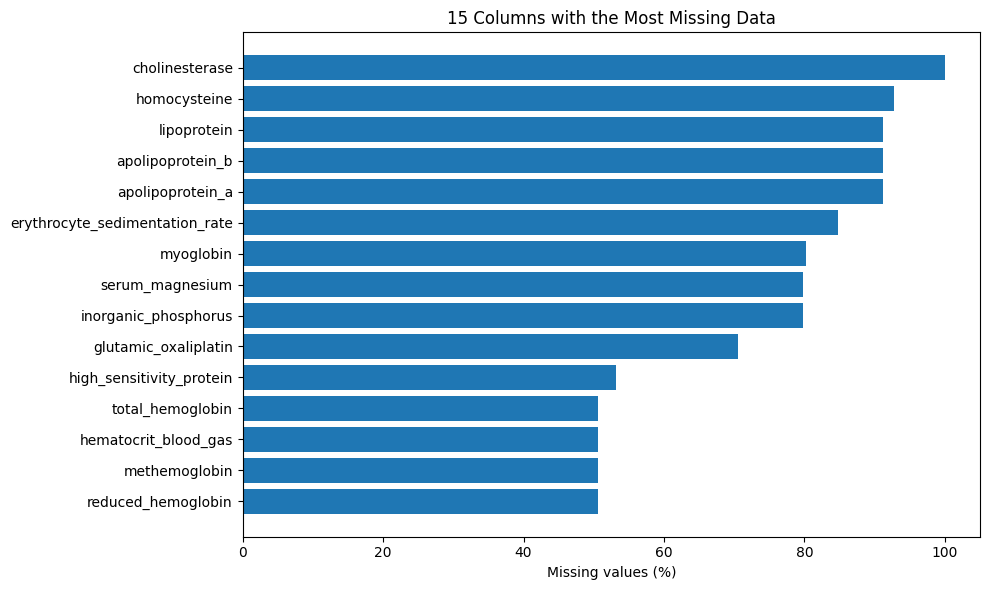

In [9]:
top_missing = missing_report.head(15).sort_values("missing_percent")

plt.figure(figsize=(10, 6))
plt.barh(top_missing.index, top_missing["missing_percent"])
plt.xlabel("Missing values (%)")
plt.title("15 Columns with the Most Missing Data")
plt.tight_layout()
plt.show()

**Actual insight:** Several infrequently recorded laboratory tests have very high missing values. The chart is for understanding missing data patterns. 

## 7. Add a Row-Level Missing Value Check

**Reason:**

Column-level missing value identifies laboratory tests that were infrequently recorded, while row-level missing values identifies patients with limited available measurements.

This helps determine whether individual records contain sufficient information for the intended analysis.

In [10]:
# Calculate missing values for each patient
missing_per_patient = df.isna().sum(axis=1)

# Identify patients with more than 50% missing measurements
high_missing_patients = df[
    df.isna().mean(axis=1) > 0.50
]

print(
    "Patients with more than 50% missing values:",
    len(high_missing_patients)
)

print(
    "Maximum missing values in a patient record:",
    missing_per_patient.max()
)

Patients with more than 50% missing values: 37
Maximum missing values in a patient record: 99


**Actual insight:** In the original dataset, 37 patients have more than 50% missing data, and the highest number of missing fields in an individual record is 99.

I would retain these patients in the main cleaned CSV but consider whether they have sufficient data for each specific analysis.

## 8. Remove columns that contain no variable information
**Reason:** In this CSV, one column is entirely blank and another has only one observed value. Dropping these from the **analysis copy** simplifies the table; the original CSV stays available.

In [11]:
# Column with no measurements at all
empty_columns = df.columns[df.isna().all()].tolist()

# Column with the same observed value wherever it is filled in
constant_columns = [
    col for col in df.columns
    if col != "inpatient_number" and df[col].nunique(dropna=True) == 1
    and df[col].notna().any()
]

columns_to_remove = empty_columns + constant_columns
print("Entirely empty columns:", empty_columns)
print("Constant observed columns:", constant_columns)

# Remove only these identified columns.
df = df.drop(columns=columns_to_remove)
print("Columns after cleaning:", df.shape[1])

Entirely empty columns: ['cholinesterase']
Constant observed columns: ['body_temperature_blood_gas']
Columns after cleaning: 105


**Actual insight:** Removed `cholinesterase` (**100% missing**) and `body_temperature_blood_gas` (**37 in every non-missing row**). The regular `body_temperature` column is **kept**. The cleaned dataset now has **105 columns**.

## 9. Find unusual results for review
**Reason:** The sample sometimes replaces or deletes suspicious values. For this clinical file, a zero vital sign, reversed blood pressure, or unusually extreme measurement needs checking against its source. We create a separate flagged-patients list rather than inventing a replacement or removing the patient.

The temperature and pH cutoffs below are **data-review screening rules**, not diagnoses or proof that a value is wrong.

In [12]:
# One True/False flag per kind of potential data-quality issue.
review_flags = pd.DataFrame({"inpatient_number": df["inpatient_number"]})

review_flags["zero_vital_sign"] = df[[
    "pulse", "respiration", "systolic_blood_pressure",
    "diastolic_blood_pressure"
]].eq(0).any(axis=1)

review_flags["reversed_blood_pressure"] = (
    df["systolic_blood_pressure"] < df["diastolic_blood_pressure"]
)
review_flags["negative_anion_gap"] = df["anion_gap"] < 0
review_flags["temperature_above_41"] = df["body_temperature"] > 41
review_flags["extreme_ph_review"] = (df["ph"] < 6.8) | (df["ph"] > 7.8)

flag_columns = review_flags.columns.drop("inpatient_number")
flagged_mask = review_flags[flag_columns].any(axis=1)

# Keep the actual measurements next to the review flags.
review_measurements = [
    "inpatient_number", "pulse", "respiration",
    "systolic_blood_pressure", "diastolic_blood_pressure",
    "anion_gap", "body_temperature", "ph"
]
flagged_records = df.loc[flagged_mask, review_measurements].copy()
for column in flag_columns:
    flagged_records[column] = review_flags.loc[flagged_mask, column]

print("Flagged patients to review:", len(flagged_records))
print("Counts by issue:")
print(review_flags[flag_columns].sum())
flagged_records

Flagged patients to review: 9
Counts by issue:
zero_vital_sign            3
reversed_blood_pressure    2
negative_anion_gap         2
temperature_above_41       1
extreme_ph_review          1
dtype: int64


,inpatient_number,pulse,respiration,systolic_blood_pressure,diastolic_blood_pressure,anion_gap,body_temperature,ph,zero_vital_sign,reversed_blood_pressure,negative_anion_gap,temperature_above_41,extreme_ph_review
97,777721,155,22,166,80,30.8,36.0,6.77,False,False,False,False,True
533,754892,78,20,0,0,26.2,36.0,7.22,True,False,False,False,False
590,769113,75,19,128,72,NaN,42.0,NaN,False,False,False,True,False
611,764993,124,24,0,0,26.1,36.0,7.05,True,False,False,False,False
691,825901,101,19,73,95,NaN,36.3,NaN,False,True,False,False,False
744,838870,126,19,117,118,20.2,36.6,7.50,False,True,False,False,False
801,810318,67,19,126,66,-1.2,36.2,7.43,False,False,True,False,False
891,794077,89,18,140,80,-0.8,36.6,7.19,False,False,True,False,False
1831,773886,0,0,0,0,NaN,36.0,NaN,True,False,False,False,False


**Actual insight:** **9 distinct patient records** have at least one review flag. These patients **remain in the cleaned CSV**; the separate flagged-records CSV helps the team decide whether any source correction is justified.

## 10. Add Negative and Zero Value Validation

**Reason:** Some laboratory measurements can legitimately contain zero or negative values, while others may require additional investigation.
We should identify these values before making any corrections. Automatically replacing all zeros or negative values could alter valid medical measurements.

In [13]:
# Identify columns containing negative values
negative_values = (df.select_dtypes(include="number") < 0).sum()

negative_values = negative_values[negative_values > 0]

print("Columns containing negative values:")
display(negative_values.to_frame("Negative Value Count"))


# Identify columns containing zero values
zero_values = (df.select_dtypes(include="number") == 0).sum()

zero_values = zero_values[zero_values > 0]

print("Columns containing zero values:")
display(zero_values.to_frame("Zero Value Count"))

Columns containing negative values:


,Negative Value Count
standard_residual_base,708
measured_residual_base,678
anion_gap,2


Columns containing zero values:


,Zero Value Count
pulse,1
respiration,1
systolic_blood_pressure,3
diastolic_blood_pressure,3
map_value,3
basophil_ratio,29
basophil_count,54
eosinophil_ratio,198
eosinophil_count,202
d_dimer,4


**Actual insight:** The residual base measurements are signed values, so negative results should not automatically be treated as errors.
The two negative anion-gap measurements are already included in your flagged-records report.

**Cleaning decision:** Retain negative values and investigate questionable records rather than replacing them automatically.

## 11. Make an explicit decision about missing values
**Reason:** Automatically replacing a missing lab result with `0`, `No`, or the column average would change the clinical meaning of the data. Unlike some Yes/No fields in the sample notebook, these are laboratory measurements. Keep blanks as missing (`NaN`) unless the project later defines an appropriate.

In [14]:
# Intentional decision: do not use df.fillna(0), df.fillna(mean),
# or df.dropna() on patients with unmeasured laboratory tests.
print("Patients retained:", len(df))
print("Missing cells in retained columns:", df.isna().sum().sum())
print("Missing pH measurements:", df["ph"].isna().sum())

Patients retained: 2008
Missing cells in retained columns: 45329
Missing pH measurements: 1015


**Actual insight:** The cleaned file keeps **all 2,008 patients**. Remaining blanks are kept blank so that Python analysis can distinguish “not recorded” from a real measurement.

## 12. Add an Outlier Detection Section

**Reason:**  Extreme values may represent unusual patient conditions, measurement errors, or differences in how laboratory results were recorded.

Descriptive statistics help identify measurements requiring investigation. They should not be used to automatically delete patients or replace measurements.

In [15]:
# Generate descriptive statistics for numerical columns
numerical_columns = df.drop(
    columns=["inpatient_number"]
)

statistics = numerical_columns.describe().T

# Display important statistical measurements
display(
    statistics[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
)

,count,mean,std,min,25%,50%,75%,max
body_temperature,2008.0,36.416484,0.439529,35.00,36.20,36.30,36.50,42.00
pulse,2008.0,85.235060,21.539214,0.00,70.00,82.00,98.00,198.00
respiration,2008.0,19.085657,1.737546,0.00,18.00,19.00,19.00,36.00
systolic_blood_pressure,2008.0,131.056773,24.741670,0.00,113.00,130.00,146.25,252.00
diastolic_blood_pressure,2008.0,76.573207,14.461247,0.00,65.00,76.00,85.00,146.00
...,...,...,...,...,...,...,...,...
partial_oxygen_pressure,993.0,108.121853,37.422666,20.00,80.00,102.00,134.00,255.00
oxyhemoglobin,992.0,94.938710,6.205458,24.30,94.50,96.60,97.80,99.10
anion_gap,993.0,14.022457,4.153747,-1.20,11.70,13.80,16.10,43.70
free_calcium,993.0,1.110393,0.052645,0.89,1.08,1.11,1.14,1.39


**Actual insight:** This section shows the distribution and identify possible outliers without unnecessarily modifying the clinical data.

## 13. Confirm the before and after results
**Reason:** It records how many records and columns changed, what was removed, and how many patients need review.

In [16]:
summary = {
    "source_file": "labs.csv",
    "original_rows": int(df_original.shape[0]),
    "original_columns": int(df_original.shape[1]),
    "cleaned_rows": int(df.shape[0]),
    "cleaned_columns": int(df.shape[1]),
    "exact_duplicate_rows_removed": int(duplicate_rows),
    "removed_columns": columns_to_remove,
    "original_missing_cells": int(df_original.isna().sum().sum()),
    "cleaned_missing_cells": int(df.isna().sum().sum()),
    "patients_flagged_for_review": int(len(flagged_records)),
    "missing_value_decision": "Retained as missing; no automatic imputation"
}

# Convert the cleaning summary dictionary into a DataFrame
summary_df = pd.DataFrame(
    summary.items(),
    columns=["Data Cleaning Metric", "Result"]
)

# Display the summary as a formatted table
display(summary_df)

,Data Cleaning Metric,Result
0,source_file,labs.csv
1,original_rows,2008
2,original_columns,107
3,cleaned_rows,2008
4,cleaned_columns,105
5,exact_duplicate_rows_removed,0
6,removed_columns,"[cholinesterase, body_temperature_blood_gas]"
7,original_missing_cells,48352
8,cleaned_missing_cells,45329
9,patients_flagged_for_review,9


**Actual insight:** The cleaning removes **2 no-information columns**, **0 patient records**, and **0 unusual measurements**. 

## 14. Save the cleaned CSV and supporting reports
**Reason:** Exporting the cleaned dataset. The three additional small files showing missing-value report, patients needing review, and the JSON summary.

In [30]:
# Save the cleaned dataset and supporting reports

# Create the output folder if it does not exist
output_folder.mkdir(exist_ok=True)

# Save the cleaned dataset
df.to_csv(
    output_folder / "Team7_CodeAvengers_Category1_DataCleaning_labs.csv",
    index=False
)

# Save the missing-value report
missing_report.to_csv(
    output_folder / "Team7_CodeAvengers_Category1_DataCleaning_lab.csv"
)

# Save the flagged patient records
flagged_records.to_csv(
    output_folder / "Team7_CodeAvengers_Category1_DataCleaning_lab.csv",
    index=False
)

# Save the cleaning summary as a JSON file
with open(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_lab", "w") as file:
    json.dump(summary, file, indent=4)

# Display the saved files and their locations
print("All files saved successfully!\n")

for file in output_folder.iterdir():
    if file.is_file():
        print("Saved:", file.name)

print("\nOutput Folder:", output_folder)
print("Final Cleaned Dataset Shape:", df.shape)

All files saved successfully!

Saved: labs_cleaned_simple.csv
Saved: labs_cleaning_summary.json
Saved: labs_flagged_records_simple.csv
Saved: labs_missing_report_simple.csv
Saved: Team7_CodeAvengers_Category1_DataCleaning_lab
Saved: Team7_CodeAvengers_Category1_DataCleaning_lab.csv
Saved: Team7_CodeAvengers_Category1_DataCleaning_labs.csv

Output Folder: C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\cleaned_data
Final Cleaned Dataset Shape: (2008, 107)


In [34]:
# Define the notebooks folder
notebook_folder = project_folder / "notebooks"

# Create the folder if it does not exist
notebook_folder.mkdir(exist_ok=True)

# Display the notebook folder location
print("Notebook Folder:", notebook_folder)

# Display existing notebooks
print("\nJupyter Notebooks Found:")

notebooks = list(notebook_folder.glob("*.ipynb"))

if notebooks:
    for notebook in notebooks:
        print(notebook.name)
else:
    print("No Jupyter Notebook found in this folder.")
    

Notebook Folder: C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\notebooks

Jupyter Notebooks Found:
Labs_Cleaned_Data.ipynb


### Final result
**2,008 patient rows × 105 columns.** The cleaned dataset was successfully exported with 2,008 patient records and 105 columns, preserving all original patients while removing two unnecessary columns. Three supporting reports were also saved: the missing-value report, flagged patient records, and cleaning summary. The original CSV remains unchanged, ensuring that the cleaning process is traceable and the dataset is ready for further analysis and visualization.